In [1]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [2]:
seed = 42

In [3]:
data_dir = Path(r"C:\Users\patka\Downloads\Visión artificial\archive")

In [4]:
def listar_imagenes(data_dir: Path):
    images = []
    labels = []
    ids = []
    for label_dir in sorted([p for p in data_dir.iterdir() if p.is_dir()]):
        label_name = label_dir.name
        for img_path in label_dir.rglob("*"):
            if img_path.suffix.lower() in ['.jpg','.jpeg','.png']:
                images.append(img_path)
                labels.append(label_dir.name)
                image_id = img_path.stem
                ids.append(image_id)
    return pd.DataFrame({"image_path": images,  "image_id": ids, "label": labels})

In [5]:
if not data_dir.exists():
    raise FileNotFoundError(f"No se encontró {data_dir}. Coloca tus imágenes en esa ruta o modifica data_dir en la celda.")

df = listar_imagenes(data_dir)
print(f"Total imágenes encontradas: {len(df)}")
df.head(-5)
   

Total imágenes encontradas: 70549


,image_path,image_id,label
0,C:\Users\patka\Downloads\Visión artificial\arc...,Apple 1,Apple
1,C:\Users\patka\Downloads\Visión artificial\arc...,Apple 10,Apple
2,C:\Users\patka\Downloads\Visión artificial\arc...,Apple 100,Apple
3,C:\Users\patka\Downloads\Visión artificial\arc...,Apple 101,Apple
4,C:\Users\patka\Downloads\Visión artificial\arc...,Apple 102,Apple
...,...,...,...
70539,C:\Users\patka\Downloads\Visión artificial\arc...,Tamotoes00990,Tomatoes
70540,C:\Users\patka\Downloads\Visión artificial\arc...,Tamotoes00991,Tomatoes
70541,C:\Users\patka\Downloads\Visión artificial\arc...,Tamotoes00992,Tomatoes
70542,C:\Users\patka\Downloads\Visión artificial\arc...,Tamotoes00993,Tomatoes


In [6]:
counts = df['label'].value_counts()
print(counts)

label
Guava          19698
Apple          11185
Kiwi            8465
Mango           4154
Banana          3027
Pear            3012
Orange          3012
Peach           2629
Pitaya          2501
Plum            2298
Tomatoes        2171
Pomegranate     2167
Carambola       2080
muskmelon       2078
Persimmon       2072
Name: count, dtype: int64


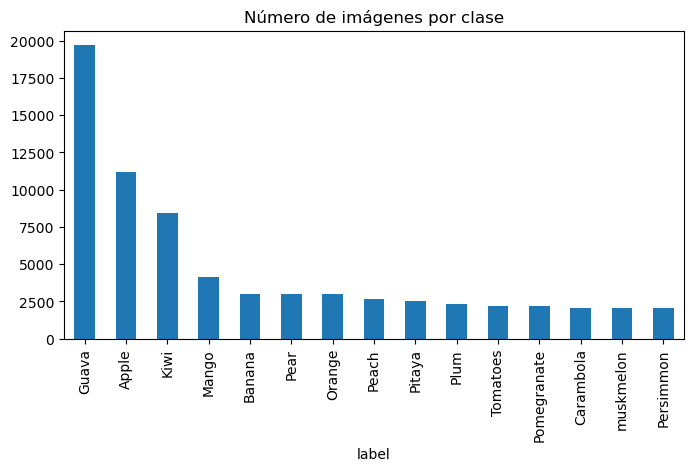

In [7]:
plt.figure(figsize=(8,4))
counts.plot(kind='bar')
plt.title('Número de imágenes por clase')
plt.show()
plt.close()

C:\Users\patka\AppData\Local\Temp\ipykernel_27516\3070140783.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1, random_state=seed))


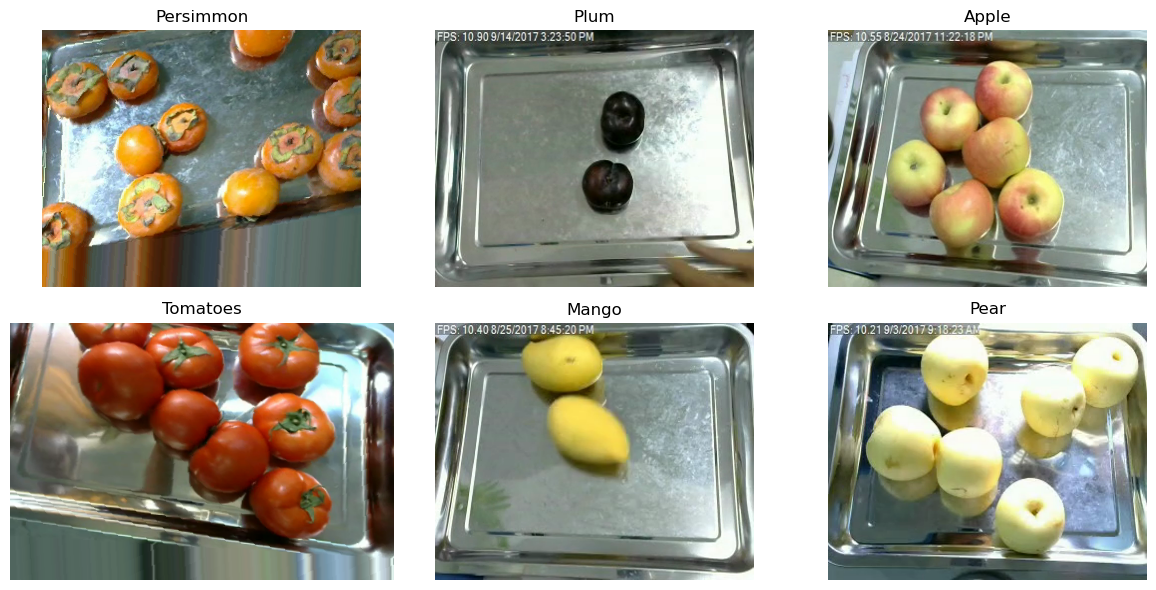

In [8]:
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

num_examples = 6

sample = (
    df.groupby('label')
      .apply(lambda x: x.sample(1, random_state=seed))
      .reset_index(drop=True)
      .sample(n=min(num_examples, len(df)), random_state=seed)
)

plt.figure(figsize=(12, 6))

for i, row in enumerate(sample.itertuples()):
    try:
        with Image.open(row.image_path) as img:   
            img = img.convert('RGB')
    except UnidentifiedImageError:
        print(f"⚠️ Imagen corrupta: {row.image_path}")
        continue

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis('off')

plt.tight_layout()
plt.show()
plt.close()

In [9]:
from PIL import Image, UnidentifiedImageError
import pandas as pd

def get_image_info(path):
    try:
        with Image.open(path) as img:
            width, height = img.size
            fmt = img.format  
            return width, height, fmt
    except UnidentifiedImageError:
        return None, None, None
    except Exception as e:
        return None, None, None

info = df['image_path'].apply(get_image_info)

df['width'], df['height'], df['format'] = zip(*info)

df[['width', 'height', 'format']].head()

,width,height,format
0,480,322,PNG
1,480,322,PNG
2,480,322,PNG
3,480,322,PNG
4,480,322,PNG


In [10]:
df[['width','height']].describe()

,width,height
count,70549.000000,70549.000000
mean,318.731095,256.157791
std,65.413927,28.687158
min,200.000000,200.000000
25%,320.000000,258.000000
50%,320.000000,258.000000
75%,320.000000,258.000000
max,480.000000,322.000000


In [11]:
df[df['width'].isna()]

,image_path,image_id,label,width,height,format


In [12]:
df['format'].value_counts()

format
PNG     66853
JPEG     3696
Name: count, dtype: int64

In [13]:
def extract_color_histogram(image_path, size=(128,128), bins=(8,8,8)): 
    img = Image.open(image_path).convert('RGB') 
    img = img.resize(size) 
    arr = np.array(img) 
    # histograma 3D 
    hist, _ = np.histogramdd(arr.reshape(-1,3), bins=bins, range=[(0,256),(0,256),(0,256)]) 
    hist = hist.flatten() 
    hist = hist / hist.sum() # normalizar 
    return hist


X = [] 
y = [] 
for row in tqdm(df.itertuples(), total=len(df)): 
    try: 
        feat = extract_color_histogram(row.image_path) 
        X.append(feat) 
        y.append(row.label) 
    except Exception: 
        continue

X = np.array(X) 
y = np.array(y)




  0%|          | 0/70549 [00:00<?, ?it/s]

In [16]:
#Train/test split reproducible

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

#Entrenar RandomForest

rf = RandomForestClassifier(n_estimators=200, random_state=seed) 
rf.fit(X_train, y_train)

#Guardar modelo con joblib

import joblib 
joblib.dump(rf, 'rf_color_hist.pkl')


['rf_color_hist.pkl']

In [17]:
y_pred = rf.predict(X_test) 
print('Accuracy RF:', accuracy_score(y_test, y_pred)) 

Accuracy RF: 0.9937632884479093


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Apple       0.99      1.00      0.99      2237
      Banana       0.99      0.95      0.97       606
   Carambola       1.00      1.00      1.00       416
       Guava       1.00      1.00      1.00      3940
        Kiwi       0.99      1.00      1.00      1693
       Mango       0.97      0.98      0.97       831
      Orange       1.00      1.00      1.00       602
       Peach       1.00      1.00      1.00       526
        Pear       0.98      0.99      0.98       602
   Persimmon       1.00      1.00      1.00       414
      Pitaya       1.00      1.00      1.00       500
        Plum       1.00      1.00      1.00       460
 Pomegranate       1.00      0.99      1.00       433
    Tomatoes       1.00      0.99      0.99       434
   muskmelon       0.99      0.96      0.98       416

    accuracy                           0.99     14110
   macro avg       0.99      0.99      0.99     14110
weighted avg       0.99   

<Figure size 2400x2000 with 0 Axes>

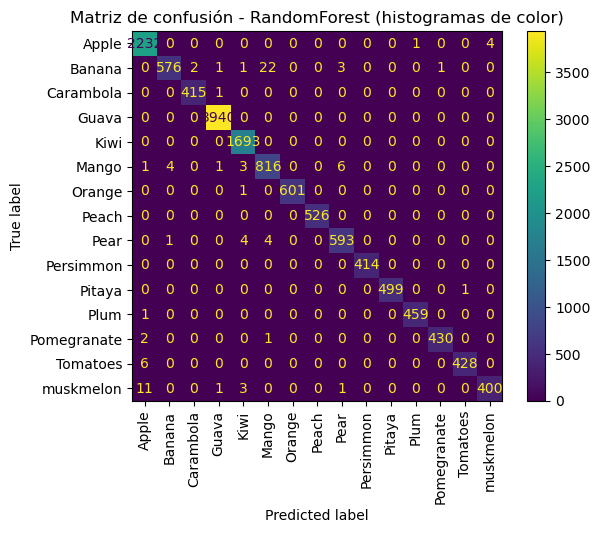

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtener predicciones del modelo
y_pred = rf.predict(X_test)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar matriz de confusión
plt.figure(figsize=(24, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='viridis', xticks_rotation=90)
plt.title("Matriz de confusión - RandomForest (histogramas de color)")
plt.show()
plt.close()

In [26]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import joblib
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder

# -------------------------------------------------------------------
# 1. Función de extracción de histogramas 
# -------------------------------------------------------------------
def extract_color_histogram(image_path, size=(128,128), bins=(8,8,8)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(size)
    arr = np.array(img)

    hist, _ = np.histogramdd(
        arr.reshape(-1, 3),
        bins=bins,
        range=[(0,256),(0,256),(0,256)]
    )

    hist = hist.flatten()
    hist = hist / hist.sum()  # normalizar
    return hist

# -------------------------------------------------------------------
# 2. Cargar modelo RandomForest previamente guardado
# -------------------------------------------------------------------
rf = joblib.load('rf_color_hist.pkl')
print("Modelo RandomForest cargado correctamente.")

# -------------------------------------------------------------------
# 3. Carpeta con imágenes sin etiqueta
# -------------------------------------------------------------------
no_etiquetados_dir = Path(r'C:\Users\patka\Downloads\Frutas no etiquetadas')
output_rows = []

if no_etiquetados_dir.exists():

    # Listar imágenes válidas
    image_paths = sorted([
        p for p in no_etiquetados_dir.iterdir()
        if p.suffix.lower() in ['.jpg', '.png', '.jpeg']
    ])

    print("Imágenes detectadas:", len(image_paths))

    # -------------------------------------------------------------------
    # 4. Extraer histogramas y predecir
    # -------------------------------------------------------------------
    for img_path in tqdm(image_paths, desc="Generando predicciones"):
        try:
            feat = extract_color_histogram(img_path)
            feat = feat.reshape(1, -1)  # RF espera forma [1, n_features]

            pred = rf.predict(feat)[0]    # etiqueta predicha

            output_rows.append({
                'image_id': img_path.name,
                'predicted_label': pred
            })

        except Exception as e:
            print(f"Error con {img_path.name}: {e}")
            continue

    # -------------------------------------------------------------------
    # 5. Guardar archivo CSV de predicciones
    # -------------------------------------------------------------------
    df_out = pd.DataFrame(output_rows)
    df_out.to_csv('predicciones_randomforest.csv', index=False)

    print("\nArchivo predicciones_randomforest.csv creado con",
          len(df_out), "filas")

else:
    print("No existe carpeta", no_etiquetados_dir,
          "- coloca tus imágenes sin etiqueta ahí para generar predicciones.")

Modelo RandomForest cargado correctamente.
Imágenes detectadas: 5


Generando predicciones: 100%|██████████| 5/5 [00:00<00:00, 11.37it/s]


Archivo predicciones_randomforest.csv creado con 5 filas
